# Analise de Escalonamento a partir de CSV

Este notebook le multiplos arquivos CSV com colunas `PID, PIT TICK, EVENT ID, CONTEXT ID` e calcula:
- media do tempo de resposta
- media do tempo de espera
- media do tempo de turnaround
- desvio padrao do tempo de espera

Depois gera graficos de coluna com seaborn comparando os arquivos.

In [10]:
from pathlib import Path
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

In [11]:
# Opcao 1: informe explicitamente os arquivos CSV aqui.
CSV_FILES = [
    '../scripts/FCFS - Maior, Médio, Menor.csv',
    '../scripts/FCFS - Menor, Médio, Maior.csv',
    '../scripts/SJF - PREEMPTIVO.csv',
    '../scripts/RR - Quantum=30ms.csv',
    '../scripts/RR - Quantum=100ms.csv'
]

# Opcao 2: descoberta automatica por padrao (se CSV_FILES estiver vazio).
CSV_GLOBS = [
    '../scripts/*.csv',
    '../out/*.csv',
    '*.csv',
]

if CSV_FILES:
    csv_paths = [Path(p) for p in CSV_FILES]
else:
    found = []
    for pattern in CSV_GLOBS:
        found.extend(glob.glob(pattern))
    csv_paths = [Path(p) for p in sorted(set(found))]

print(f'Arquivos detectados: {len(csv_paths)}')
for p in csv_paths:
    print('-', p)

Arquivos detectados: 5
- ../scripts/FCFS - Maior, Médio, Menor.csv
- ../scripts/FCFS - Menor, Médio, Maior.csv
- ../scripts/SJF - PREEMPTIVO.csv
- ../scripts/RR - Quantum=30ms.csv
- ../scripts/RR - Quantum=100ms.csv


In [12]:
# IDs de eventos usados pelo kernel
EVENT_CREATED = 0
EVENT_SCHEDULED = 1
EVENT_YIELDED = 2
EVENT_PREEMPTED = 3
EVENT_TERMINATED = 4

STOP_EVENTS = {EVENT_YIELDED, EVENT_PREEMPTED, EVENT_TERMINATED}
ASSUME_READY_FROM_TICK_ZERO = True

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    col_map = {
        'PID': 'PID',
        'PIT TICK': 'PIT TICK',
        'PIT_TICK': 'PIT TICK',
        'PITTICK': 'PIT TICK',
        'EVENT ID': 'EVENT ID',
        'EVENT_ID': 'EVENT ID',
        'EVENTID': 'EVENT ID',
        'CONTEXT ID': 'CONTEXT ID',
        'CONTEXT_ID': 'CONTEXT ID',
        'CONTEXTID': 'CONTEXT ID',
    }

    renamed = {}
    for c in df.columns:
        key = str(c).strip().upper().replace('-', ' ').replace('  ', ' ')
        key = key.replace('_', ' ')
        key = ' '.join(key.split())
        if key in col_map:
            renamed[c] = col_map[key]

    out = df.rename(columns=renamed).copy()
    required = ['PID', 'PIT TICK', 'EVENT ID', 'CONTEXT ID']
    missing = [c for c in required if c not in out.columns]
    if missing:
        raise ValueError(f'Colunas ausentes: {missing}')

    for c in required:
        out[c] = pd.to_numeric(out[c], errors='coerce')

    out = out.dropna(subset=required).astype({
        'PID': int,
        'PIT TICK': int,
        'EVENT ID': int,
        'CONTEXT ID': int,
    })
    out = out.reset_index(drop=True)
    out['__order__'] = np.arange(len(out))
    return out

def compute_pid_metrics(df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for pid, g in df.groupby('PID'):
        g = g.sort_values(['PIT TICK', '__order__']).reset_index(drop=True)

        scheduled_events = g[g['EVENT ID'] == EVENT_SCHEDULED]
        terminated_events = g[g['EVENT ID'] == EVENT_TERMINATED]

        # Hipotese solicitada: processos existem e estao em READY desde o tick 0.
        created_tick = 0 if ASSUME_READY_FROM_TICK_ZERO else int(g['PIT TICK'].iloc[0])
        first_schedule_tick = int(scheduled_events['PIT TICK'].iloc[0]) if not scheduled_events.empty else created_tick
        terminated_tick = int(terminated_events['PIT TICK'].iloc[-1]) if not terminated_events.empty else int(g['PIT TICK'].iloc[-1])

        response_time = first_schedule_tick - created_tick
        turnaround_time = terminated_tick - created_tick

        waiting_time = 0
        ready_enter_tick = created_tick

        for _, ev in g.iterrows():
            tick = int(ev['PIT TICK'])
            event_id = int(ev['EVENT ID'])

            if event_id == EVENT_SCHEDULED:
                if ready_enter_tick is not None:
                    waiting_time += max(0, tick - ready_enter_tick)
                ready_enter_tick = None
            elif event_id in {EVENT_YIELDED, EVENT_PREEMPTED}:
                ready_enter_tick = tick
            elif event_id == EVENT_TERMINATED:
                ready_enter_tick = None

        rows.append({
            'PID': pid,
            'response_time': response_time,
            'waiting_time': waiting_time,
            'turnaround_time': turnaround_time,
        })

    return pd.DataFrame(rows)

all_pid_metrics = []
summary_rows = []

for csv_path in csv_paths:
    raw = pd.read_csv(csv_path)
    data = normalize_columns(raw)
    pid_metrics = compute_pid_metrics(data)
    pid_metrics['file'] = csv_path.name
    all_pid_metrics.append(pid_metrics)

    summary_rows.append({
        'file': csv_path.name,
        'media_tempo_resposta': pid_metrics['response_time'].mean(),
        'media_tempo_espera': pid_metrics['waiting_time'].mean(),
        'media_tempo_turnaround': pid_metrics['turnaround_time'].mean(),
        'desvio_padrao_tempo_espera': pid_metrics['waiting_time'].std(ddof=0),
    })

pid_metrics_df = pd.concat(all_pid_metrics, ignore_index=True) if all_pid_metrics else pd.DataFrame()
summary_df = pd.DataFrame(summary_rows)

print('Metricas por processo:')
display(pid_metrics_df)

print('Resumo por arquivo:')
display(summary_df)

Metricas por processo:


,PID,response_time,waiting_time,turnaround_time,file
0,1,0,0,2890,"FCFS - Maior, Médio, Menor.csv"
1,2,2890,2890,3364,"FCFS - Maior, Médio, Menor.csv"
2,3,3364,3364,3413,"FCFS - Maior, Médio, Menor.csv"
3,1,0,0,44,"FCFS - Menor, Médio, Maior.csv"
4,2,44,44,600,"FCFS - Menor, Médio, Maior.csv"
5,3,600,600,3189,"FCFS - Menor, Médio, Maior.csv"
6,1,3,963,4536,SJF - PREEMPTIVO.csv
7,2,1,964,1814,SJF - PREEMPTIVO.csv
8,3,2,228,341,SJF - PREEMPTIVO.csv
9,1,9,1091,4130,RR - Quantum=30ms.csv


Resumo por arquivo:


,file,media_tempo_resposta,media_tempo_espera,media_tempo_turnaround,desvio_padrao_tempo_espera
0,"FCFS - Maior, Médio, Menor.csv",2084.666667,2084.666667,3222.333333,1486.729147
1,"FCFS - Menor, Médio, Maior.csv",214.666667,214.666667,1277.666667,273.063281
2,SJF - PREEMPTIVO.csv,2.000000,718.333333,2230.333333,346.718265
3,RR - Quantum=30ms.csv,6.000000,910.000000,2286.666667,257.388163
4,RR - Quantum=100ms.csv,20.000000,542.000000,1895.666667,284.286241


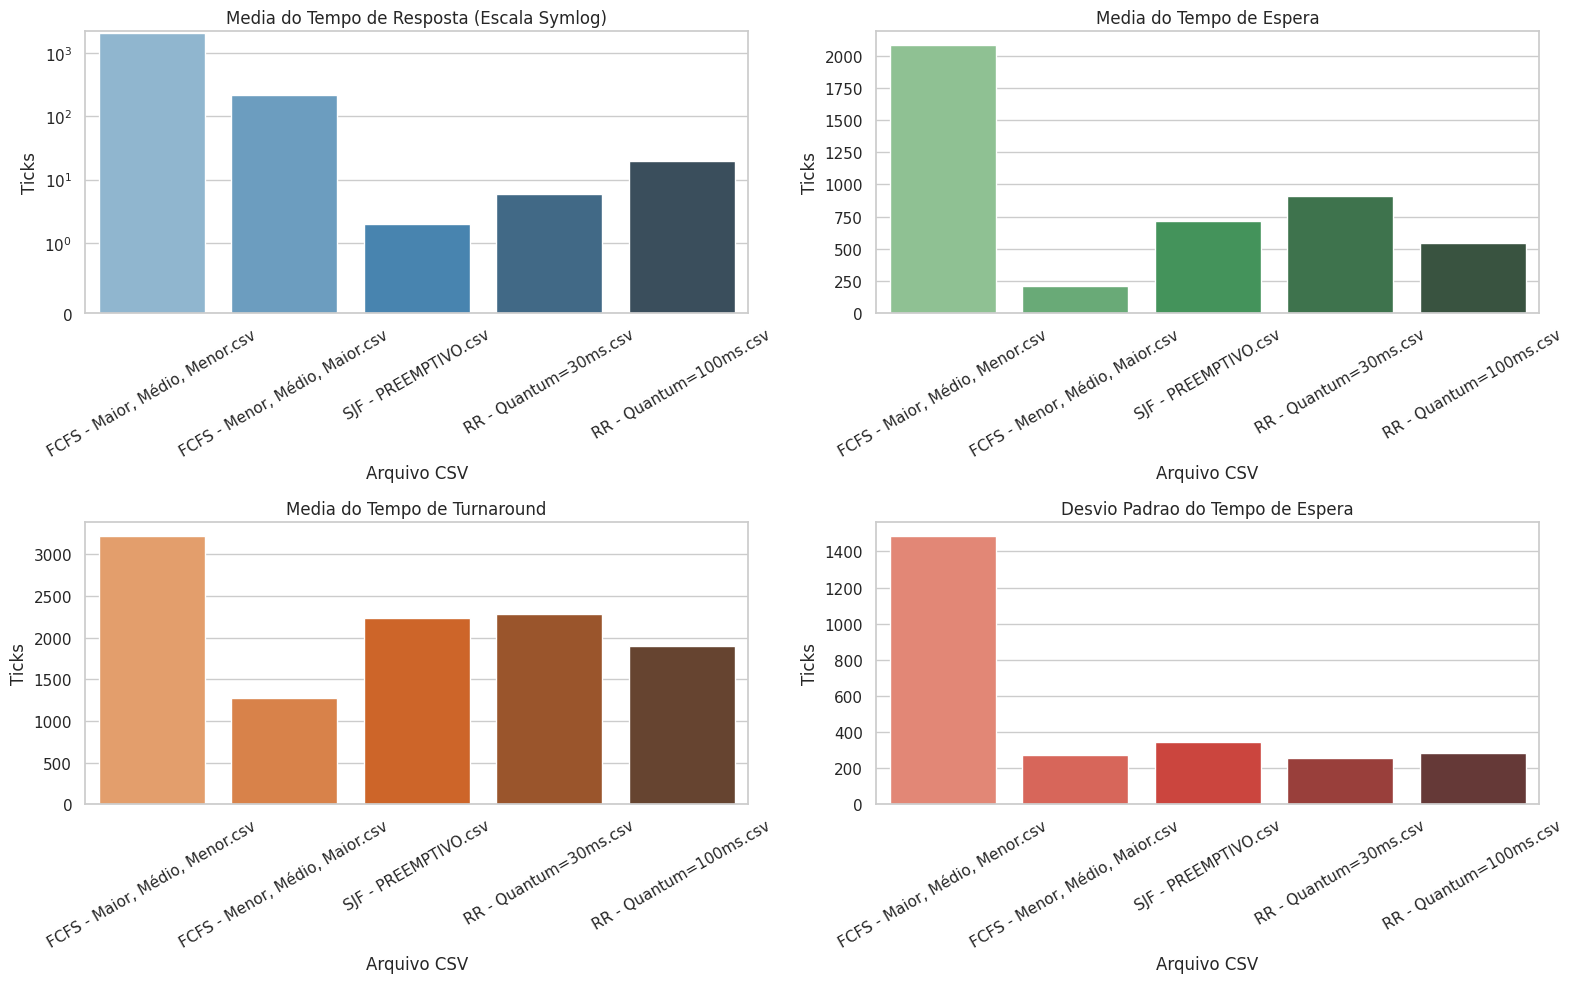

In [17]:
if summary_df.empty:
    print('Nenhum CSV encontrado. Preencha CSV_FILES ou adicione arquivos nos caminhos configurados.')
else:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    sns.barplot(data=summary_df, x='file', y='media_tempo_resposta', hue='file', legend=False, ax=axes[0, 0], palette='Blues_d')
    axes[0, 0].set_title('Media do Tempo de Resposta (Escala Symlog)')
    axes[0, 0].set_xlabel('Arquivo CSV')
    axes[0, 0].set_ylabel('Ticks')
    axes[0, 0].set_yscale('symlog', linthresh=1)
    axes[0, 0].tick_params(axis='x', rotation=30)

    sns.barplot(data=summary_df, x='file', y='media_tempo_espera', hue='file', legend=False, ax=axes[0, 1], palette='Greens_d')
    axes[0, 1].set_title('Media do Tempo de Espera')
    axes[0, 1].set_xlabel('Arquivo CSV')
    axes[0, 1].set_ylabel('Ticks')
    axes[0, 1].tick_params(axis='x', rotation=30)

    sns.barplot(data=summary_df, x='file', y='media_tempo_turnaround', hue='file', legend=False, ax=axes[1, 0], palette='Oranges_d')
    axes[1, 0].set_title('Media do Tempo de Turnaround')
    axes[1, 0].set_xlabel('Arquivo CSV')
    axes[1, 0].set_ylabel('Ticks')
    axes[1, 0].tick_params(axis='x', rotation=30)

    sns.barplot(data=summary_df, x='file', y='desvio_padrao_tempo_espera', hue='file', legend=False, ax=axes[1, 1], palette='Reds_d')
    axes[1, 1].set_title('Desvio Padrao do Tempo de Espera')
    axes[1, 1].set_xlabel('Arquivo CSV')
    axes[1, 1].set_ylabel('Ticks')
    axes[1, 1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()

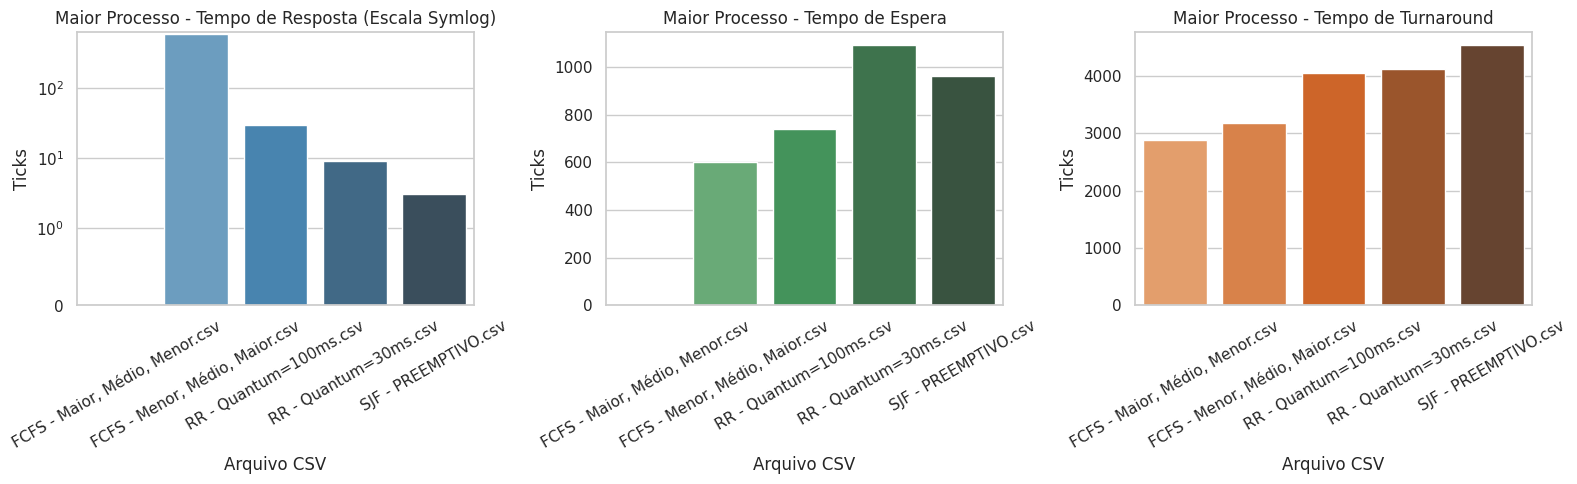

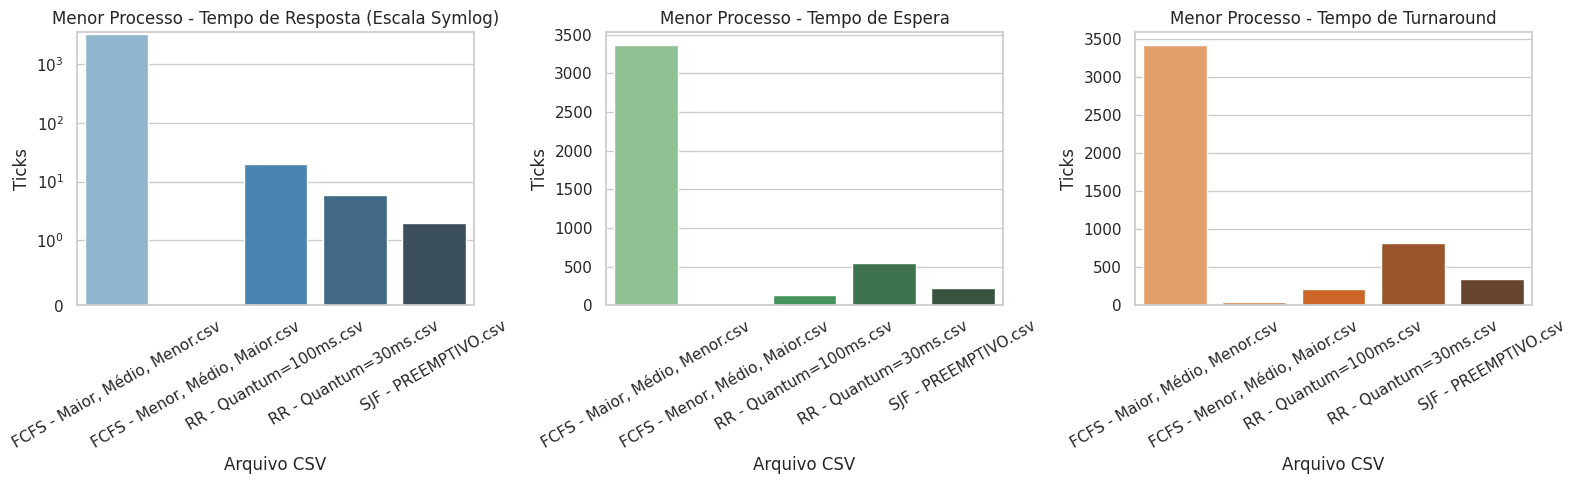

In [29]:
if pid_metrics_df.empty:
    print('pid_metrics_df vazio. Execute a celula de calculo das metricas primeiro.')
else:
    # Copia para visualizacao por PID sem alterar os dados originais.
    pid_metrics_plot_df = pid_metrics_df.copy()

    # Regra solicitada: apenas neste arquivo, trocar PID 1 <-> 3 para representar menor/maior processo.
    target_file = 'FCFS - Menor, Médio, Maior.csv'
    swap_mask = pid_metrics_plot_df['file'] == target_file
    pid_metrics_plot_df.loc[swap_mask, 'PID'] = pid_metrics_plot_df.loc[swap_mask, 'PID'].replace({1: 3, 3: 1})

    # Agrega por arquivo e PID para manter o mesmo conjunto de estatisticas do layout principal.
    # (para desvio padrao com um unico valor por arquivo/PID, o resultado tende a 0)
    pid_summary_df = (
        pid_metrics_plot_df
        .groupby(['file', 'PID'], as_index=False)
        .agg(
            media_tempo_resposta=('response_time', 'mean'),
            media_tempo_espera=('waiting_time', 'mean'),
            media_tempo_turnaround=('turnaround_time', 'mean'),
        )
    )

    target_pids = [1, 3]

    for target_pid in target_pids:
        pid_data = pid_summary_df[pid_summary_df['PID'] == target_pid].copy()

        if pid_data.empty:
            print(f'Sem dados para PID={target_pid}.')
            continue

        fig, axes = plt.subplots(1, 3, figsize=(16, 5))

        sns.barplot(
            data=pid_data,
            x='file',
            y='media_tempo_resposta',
            hue='file',
            legend=False,
            ax=axes[0],
            palette='Blues_d'
        )
        axes[0].set_title(f'{"Maior Processo" if target_pid == 1 else "Menor Processo"} - Tempo de Resposta (Escala Symlog)')
        axes[0].set_xlabel('Arquivo CSV')
        axes[0].set_ylabel('Ticks')
        axes[0].set_yscale('symlog', linthresh=1)
        axes[0].tick_params(axis='x', rotation=30)

        sns.barplot(
            data=pid_data,
            x='file',
            y='media_tempo_espera',
            hue='file',
            legend=False,
            ax=axes[1],
            palette='Greens_d'
        )
        axes[1].set_title(f'{"Maior Processo" if target_pid == 1 else "Menor Processo"} - Tempo de Espera')
        axes[1].set_xlabel('Arquivo CSV')
        axes[1].set_ylabel('Ticks')
        axes[1].tick_params(axis='x', rotation=30)

        sns.barplot(
            data=pid_data,
            x='file',
            y='media_tempo_turnaround',
            hue='file',
            legend=False,
            ax=axes[2],
            palette='Oranges_d'
        )
        axes[2].set_title(f'{"Maior Processo" if target_pid == 1 else "Menor Processo"} - Tempo de Turnaround')
        axes[2].set_xlabel('Arquivo CSV')
        axes[2].set_ylabel('Ticks')
        axes[2].tick_params(axis='x', rotation=30)

        plt.tight_layout()
        plt.show()